# 🧠 Handwritten Digit Classification using Neural Networks (MNIST)

This notebook explains **everything from scratch**:
- Reading the dataset
- Understanding images as numbers
- Preprocessing
- Building a Neural Network
- Training and prediction

This is written to be **beginner-friendly and interview-ready**.

## Step 1: Import Required Libraries

- NumPy → numerical operations
- Matplotlib → image visualization
- TensorFlow / Keras → Neural Network

In [ ]:
!pip install tensorflow # if not installed

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

2026-01-21 15:30:14.089396: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-21 15:30:14.853935: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-21 15:30:17.208901: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/siva/anaconda3/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## Step 2: Load the MNIST Dataset

MNIST contains handwritten digits (0–9).
- Each image is **28 × 28 pixels**
- Pixel values range from **0 to 255**

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

## Step 3: Dataset Size

In [3]:
print('Training images:', len(x_train))
print('Training labels:', len(y_train))
print('Test images:', len(x_test))
print('Test labels:', len(y_test))

Training images: 60000
Training labels: 60000
Test images: 10000
Test labels: 10000


## Step 4: Inspect One Image

Images are stored as **NumPy arrays**, not image files.

In [5]:
type(x_train)
x_train[0].shape

(28, 28)

In [8]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

## Step 5: Visualize the Image

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

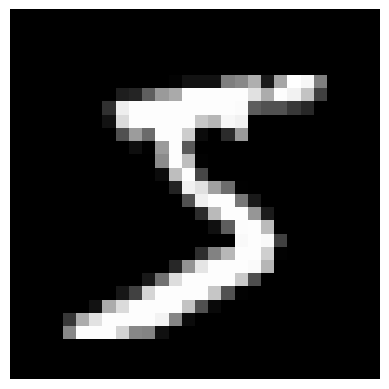

In [9]:
plt.imshow(x_train[0], cmap='gray')
plt.axis('off')

## Step 6: Normalize Pixel Values

Neural Networks perform better when inputs are between **0 and 1**.

In [10]:
X_train = x_train / 255
X_test = x_test / 255

In [11]:
X_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

## Step 7: Flatten Images

Dense layers require **1D input**.
28 × 28 → 784 features

In [12]:
X_train_flattened = X_train.reshape(len(X_train), 784)
X_test_flattened = X_test.reshape(len(X_test), 784)

X_train_flattened.shape

(60000, 784)

In [13]:
X_train_flattened[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

## Step 8: Build the Neural Network

- Input layer → 784 neurons
- Output layer → 10 neurons (digits 0–9)

In [14]:
model = keras.Sequential([
    keras.Input(shape=(784,)),
    keras.layers.Dense(10, activation='sigmoid')
])

2026-01-21 15:36:39.011750: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Step 9: Compile the Model

In [15]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Step 10: Train the Model

In [16]:
model.fit(X_train_flattened, y_train, epochs=5)

Epoch 1/5


2026-01-21 15:36:54.924118: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 188160000 exceeds 10% of free system memory.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8774 - loss: 0.4685
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9150 - loss: 0.3042
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9216 - loss: 0.2835
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9233 - loss: 0.2732
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9262 - loss: 0.2670


## Step 11: Make Predictions

In [17]:
y_predicted = model.predict(X_test_flattened)
predicted_digit = y_predicted[0]
predicted_digit

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([2.51605939e-02, 4.56657062e-07, 6.83364421e-02, 9.60185468e-01,
       2.83596315e-03, 1.02665909e-01, 2.11028532e-06, 9.99822676e-01,
       1.07634254e-01, 6.87941670e-01], dtype=float32)

In [19]:
y_test[0]

np.uint8(7)

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

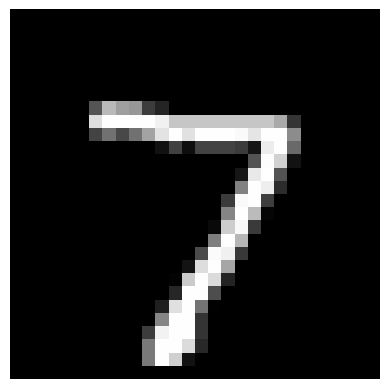

In [21]:
plt.imshow(x_test[0], cmap='gray')
plt.axis('off')

In [11]:
y_predicted = model.predict(X_test_flattened)
predicted_digit = np.argmax(y_predicted[0])

print('Predicted digit:', predicted_digit)
print('Actual digit:', y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 523us/step


2026-01-08 20:02:20.180360: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 31360000 exceeds 10% of free system memory.


Predicted digit: 7
Actual digit: 7


## Step 12: Visual Confirmation

In [ ]:
plt.imshow(x_test[0], cmap='gray')
plt.axis('off')

## ✅ Summary

You have successfully:
- Loaded image data
- Converted images to numbers
- Normalized and flattened data
- Built and trained a Neural Network
- Made predictions

This is a **complete MNIST baseline model**.